In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/icebearogo/eye-detection-dataset/Dataset/val/labels.cache
/kaggle/input/datasets/icebearogo/eye-detection-dataset/Dataset/val/labels/i_1254_jpg.rf.e14caead5d9f44f61d9132ec2b52e2a2.txt
/kaggle/input/datasets/icebearogo/eye-detection-dataset/Dataset/val/labels/i_1376_jpg.rf.45e76e3f983ab59359b95349c6401728.txt
/kaggle/input/datasets/icebearogo/eye-detection-dataset/Dataset/val/labels/i_735_png.rf.d44e340f8315fc03a37b51eb51506150.txt
/kaggle/input/datasets/icebearogo/eye-detection-dataset/Dataset/val/labels/i_927_png.rf.79f1187f40b7602fb19e518ee1bdd89d.txt
/kaggle/input/datasets/icebearogo/eye-detection-dataset/Dataset/val/labels/i_1161_jpg.rf.5416aa90dd613d22c5d337910295e052.txt
/kaggle/input/datasets/icebearogo/eye-detection-dataset/Dataset/val/labels/image_110_png.rf.15b3a3bbbf082b2d232d7b649964f4b2.txt
/kaggle/input/datasets/icebearogo/eye-detection-dataset/Dataset/val/labels/i_232_jpg.rf.76444640d6b296cd7a9421aac97f823a.txt
/kaggle/input/datasets/icebearogo/eye

In [2]:
import os
import numpy as np
import pandas as pd

In [3]:
# Import libraries for image processing and visualization
import cv2
import matplotlib.pyplot as plt

## Explore Dataset Structure

In [4]:
os.listdir('/kaggle/input')

['datasets']

In [5]:
os.listdir('/kaggle/input/datasets')

['icebearogo']

In [6]:
os.listdir('/kaggle/input/datasets/icebearogo')

['eye-detection-dataset']

In [7]:
os.listdir('/kaggle/input/datasets/icebearogo/eye-detection-dataset')

['Dataset']

In [8]:
os.listdir('/kaggle/input/datasets/icebearogo/eye-detection-dataset/Dataset')

['val', 'test', 'train']

In [9]:
os.listdir('/kaggle/input/datasets/icebearogo/eye-detection-dataset/Dataset/train')

['labels', 'labels.cache', 'images']

In [10]:
train_images = '/kaggle/input/datasets/icebearogo/eye-detection-dataset/Dataset/train/images'

## Number of Training Images


In [11]:
len(os.listdir(train_images))

1385

# Import libraries for image processing and visualization
import cv2
import matplotlib.pyplot as plt

# Select the first image from the training folder
img_path = os.path.join(train_images, os.listdir(train_images)[0])

# Load the image using OpenCV
img = cv2.imread(img_path)

# Convert the color format from BGR to RGB for correct display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display the image
plt.imshow(img_rgb)
plt.axis('off')

(np.float64(-0.5), np.float64(119.5), np.float64(79.5), np.float64(-0.5))

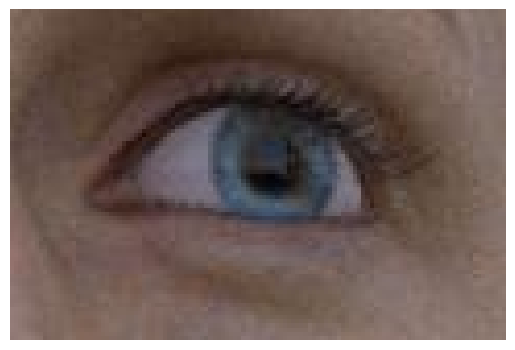

In [12]:
# Import libraries for image processing and visualization
import cv2
import matplotlib.pyplot as plt

# Select the first image from the training folder
img_path = os.path.join(train_images, os.listdir(train_images)[0])

# Load the image using OpenCV
img = cv2.imread(img_path)

# Convert the color format from BGR to RGB for correct display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display the image
plt.imshow(img_rgb)
plt.axis('off')

## Inspecting Annotation Labels

The dataset contains annotation files that store the bounding box
coordinates for the eyes in each image.

These annotations are used to train object detection models.
We will inspect one label file to understand the annotation format.

In [13]:
train_labels = "/kaggle/input/datasets/icebearogo/eye-detection-dataset/Dataset/train/labels"

os.listdir(train_labels)[:5]

['i_1264_jpg.rf.35346c94527db34a970e5d4959ed6b31.txt',
 'PHOTO-2023-07-27-12-41-25-2-_jpg.rf.945906016fade168a4b16cd72878c997.txt',
 'image_27_png.rf.c30d37fe9319613de81cefa00b474209.txt',
 'i_1082_jpg.rf.97c313fb707fa28fe0dd3713d657d2d5.txt',
 'i_1006_jpg.rf.dbaaa4eb244c4e07130e2cd2f7beea03.txt']

### Inspecting one annotation file

Each label file contains the bounding box information for the eye
in the corresponding image.  
We inspect one file to understand the annotation format.

In [14]:
label_file = os.listdir(train_labels)[0]

with open(os.path.join(train_labels, label_file), "r") as f:
    print(f.read())

0 0.583448275862069 0.5153448275862069 0.28206896551724137 0.22948275862068968


### Visualizing the bounding box

We draw the bounding box from the label file onto the image
to verify that the annotations are correct.

(np.float64(-0.5), np.float64(119.5), np.float64(79.5), np.float64(-0.5))

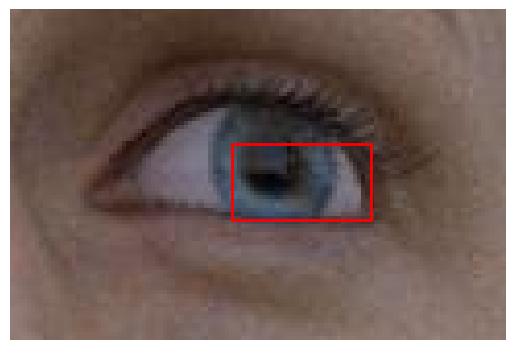

In [15]:
import matplotlib.patches as patches

# read label
with open(os.path.join(train_labels, label_file), "r") as f:
    line = f.readline().split()

class_id, x_center, y_center, width, height = map(float, line)

img_h, img_w, _ = img_rgb.shape

# convert YOLO format to pixel coordinates
x_center *= img_w
y_center *= img_h
width *= img_w
height *= img_h

x = x_center - width / 2
y = y_center - height / 2

fig, ax = plt.subplots(1)
ax.imshow(img_rgb)

rect = patches.Rectangle((x, y), width, height,
                         linewidth=2, edgecolor='red',
                         facecolor='none')

ax.add_patch(rect)
plt.axis("off")

## Visualizing Multiple Labeled Images

To better understand the dataset, we visualize several images
together with their bounding box annotations.

This helps verify that the labels are correctly aligned with
the images and that the dataset is suitable for training an
object detection model.

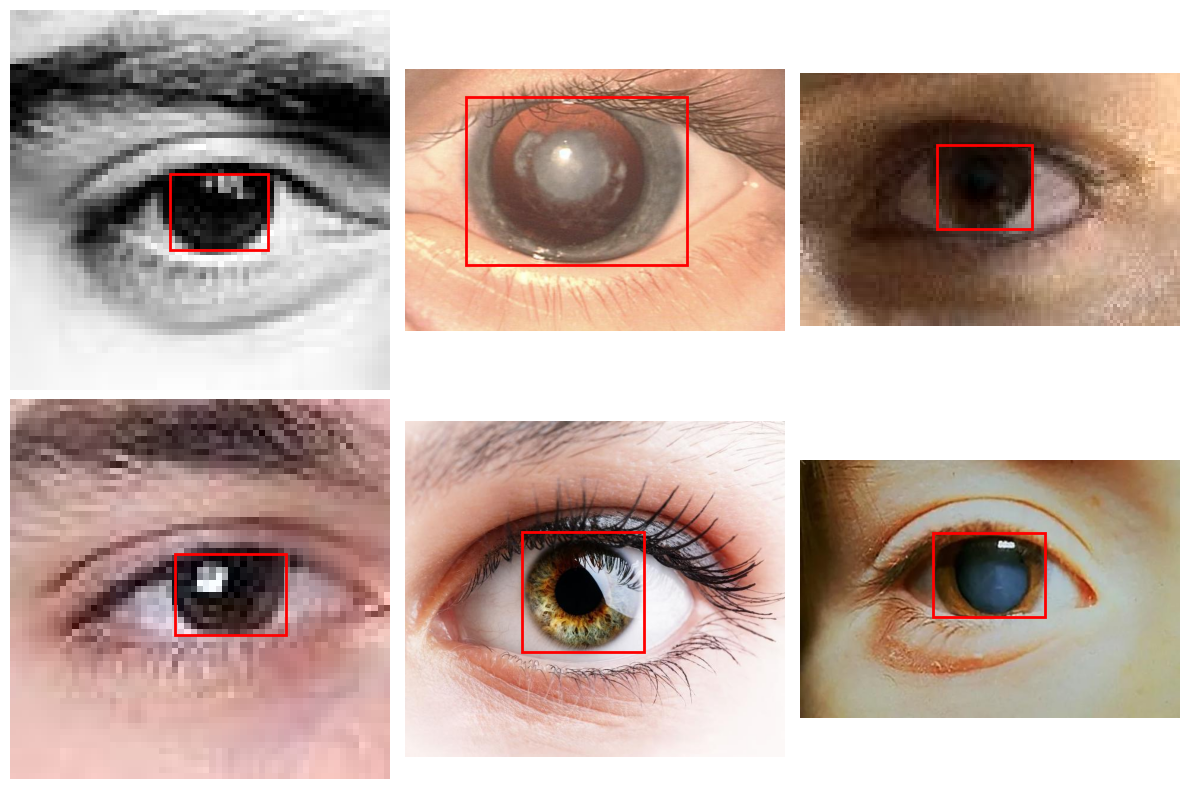

In [16]:
import random
import matplotlib.patches as patches

image_files = os.listdir(train_images)

fig, axs = plt.subplots(2, 3, figsize=(12,8))

for ax in axs.flatten():

    img_name = random.choice(image_files)
    img_path = os.path.join(train_images, img_name)

    label_name = img_name.replace(".jpg", ".txt").replace(".png",".txt")
    label_path = os.path.join(train_labels, label_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w, _ = img.shape

    with open(label_path) as f:
        line = f.readline().split()

    _, xc, yc, bw, bh = map(float, line)

    xc *= w
    yc *= h
    bw *= w
    bh *= h

    x = xc - bw/2
    y = yc - bh/2

    ax.imshow(img)

    rect = patches.Rectangle((x,y), bw, bh,
                             linewidth=2,
                             edgecolor="red",
                             facecolor="none")

    ax.add_patch(rect)
    ax.axis("off")

plt.tight_layout()

## Bounding Box Size Distribution

To better understand the dataset we analyze the distribution
of bounding box sizes across the training set.

Text(0.5, 1.0, 'Bounding Box Height Distribution')

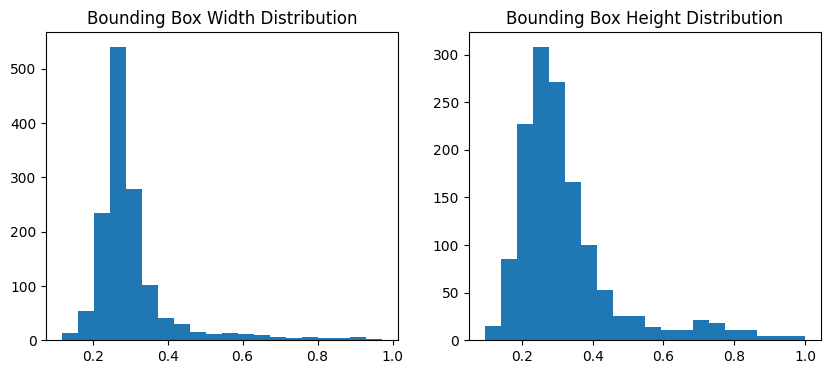

In [17]:
widths = []
heights = []

for file in os.listdir(train_labels):

    with open(os.path.join(train_labels, file)) as f:
        line = f.readline().split()

    _, xc, yc, w, h = map(float, line)

    widths.append(w)
    heights.append(h)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(widths, bins=20)
plt.title("Bounding Box Width Distribution")

plt.subplot(1,2,2)
plt.hist(heights, bins=20)
plt.title("Bounding Box Height Distribution")

## Dataset Summary

The dataset contains 1385 training images of human eyes.
Annotations are provided in YOLO format.

Initial exploration shows that the bounding boxes
are well aligned with the eyes in the images,
suggesting that the dataset is suitable for
training an object detection model.


## Possible Next Steps

Further improvements could include:

- training an object detection model such as YOLO
- evaluating model performance
- applying the model to new eye images
- integrating the model into real-time applications